# Nome: Luiz Osmar Cunha Augusto Ruiz
# Matrícula: *aluno especial*

## Import all packages need in the cell below

In [3]:
import Pkg
Pkg.add(["JuMP","HiGHS","Ipopt","Optim", "NLsolve"])
Pkg.add("JuMP")
Pkg.add("HiGHS")
Pkg.add("Ipopt")
Pkg.add("Optim")
Pkg.add("NLsolve")

    Updating registry at `~/.julia/registries/General.toml`
   Resolving package versions...
   Installed Distances ──────────────── v0.10.12
   Installed MUMPS_seq_jll ──────────── v500.800.200+0
   Installed NLsolve ────────────────── v4.5.1
   Installed HiGHS_jll ──────────────── v1.14.0+0
   Installed OpenBLAS32_jll ─────────── v0.3.33+0
   Installed MutableArithmetics ─────── v1.7.1
   Installed CodecBzip2 ─────────────── v0.8.5
   Installed NLSolversBase ──────────── v7.10.0
   Installed METIS_jll ──────────────── v5.1.3+0
   Installed MathOptInterface ───────── v1.51.0
   Installed PositiveFactorizations ─── v0.2.4
   Installed Ipopt_jll ──────────────── v300.1400.1901+0
   Installed Hwloc_jll ──────────────── v2.13.0+1
   Installed ASL_jll ────────────────── v0.1.3+0
   Installed SPRAL_jll ──────────────── v2025.9.18+0
   Installed LineSearches ───────────── v7.5.1
   Installed FiniteDiff ─────────────── v2.31.0
   Installed JuMP ───────────────────── v1.30.1
   Installed Optim

In [4]:
using JuMP
using HiGHS
using Plots
using Ipopt
using Optim
using NLsolve

## FONC example

Plot the graphics of $f(x) = (x_1 - 3)^2 + (x_2 + 4)^2$

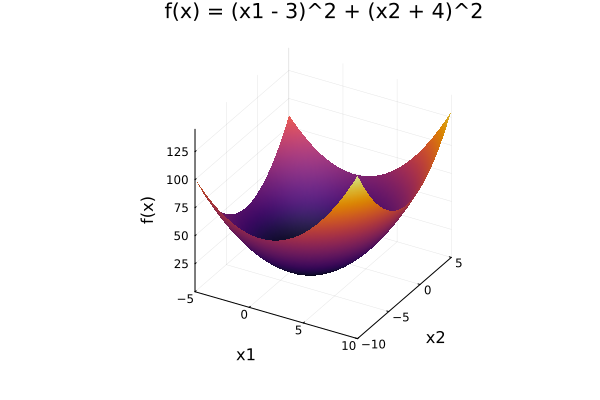

In [5]:
# Intervalos
x1 = range(-5, 10, length=100)
x2 = range(-10, 5, length=100)

# Função
f(x1, x2) = (x1 - 3)^2 + (x2 + 4)^2

# Matriz Z
z = [f(a, b) for a in x1, b in x2]

# Gráfico 3D
surface(
    x1,
    x2,
    z,
    xlabel = "x1",
    ylabel = "x2",
    zlabel = "f(x)",
    title = "f(x) = (x1 - 3)^2 + (x2 + 4)^2",
    legend = false
)

## Solving the FONC

Given the function $z = (x_1 - 1)^4 + (x_2 - 2)^4$:

* using the optim.jl package, find the minimum of z.
* using the NLsolve.jl package, solve the FONC problem for this function

In [6]:
f(x) = (x[1] - 1)^4 + (x[2] - 2)^4

x0 = [0.0, 0.0]

result = optimize(f, x0, BFGS())

println("Status: ", Optim.converged(result))
println("Mínimo em x = ", Optim.minimizer(result))
println("Valor mínimo z = ", Optim.minimum(result))

function fonc!(F, x)
    F[1] = 4 * (x[1] - 1)^3
    F[2] = 4 * (x[2] - 2)^3
end

x0 = [0.0, 0.0]

result = nlsolve(fonc!, x0)

println("Status: ", converged(result))
println("Solução da FONC x = ", result.zero)



Status: true
Mínimo em x = [0.9993307703501523, 2.0007158804901986]
Valor mínimo z = 4.632267842351608e-13
Status: true
Solução da FONC x = [0.9995401607802424, 1.9990803216092672]


Plot the level curve and the graphics of $f(x) = (x_1 - 3)^2 + (x_2 - 2)^2$

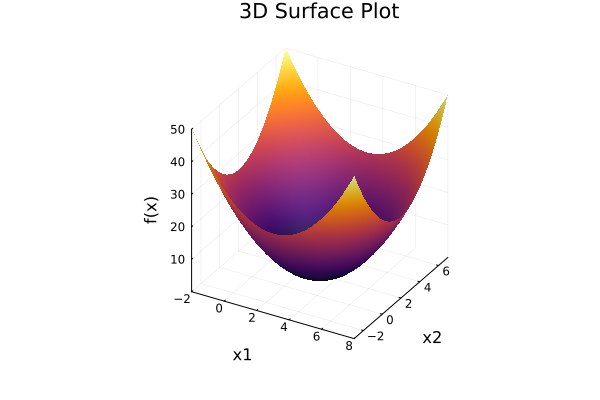

In [7]:
using Plots

# Intervalos
x1 = range(-2, 8, length=100)
x2 = range(-3, 7, length=100)

# Função
f(x1, x2) = (x1 - 3)^2 + (x2 - 2)^2

# Matriz Z
z = [f(a, b) for a in x1, b in x2]

# =========================
# Gráfico 3D
# =========================

surface(
    x1,
    x2,
    z,
    xlabel = "x1",
    ylabel = "x2",
    zlabel = "f(x)",
    title = "3D Surface Plot",
    legend = false
)

Starting from the point $x = [1.0, 1.0]$, implement the gradient descent and Newton method to find the minimum of this function.

In [8]:
using LinearAlgebra

# Função
f(x) = (x[1] - 3)^2 + (x[2] - 2)^2

# Gradiente
grad_f(x) = [
    2 * (x[1] - 3),
    2 * (x[2] - 2)
]

# Hessiana
hess_f(x) = [
    2.0 0.0;
    0.0 2.0
]

# =========================
# Gradient Descent
# =========================

function gradient_descent(x0; α=0.1, max_iter=100, tol=1e-6)
    x = copy(x0)

    println("===================================")
    println("        GRADIENT DESCENT")
    println("===================================")

    for k in 1:max_iter
        g = grad_f(x)

        println("Iteração ", k,
                " | x = ", x,
                " | f(x) = ", round(f(x), digits=6),
                " | ||grad|| = ", round(norm(g), digits=6))

        if norm(g) < tol
            break
        end

        x = x - α * g
    end

    return x
end

# =========================
# Newton Method
# =========================

function newton_method(x0; max_iter=20, tol=1e-6)
    x = copy(x0)

    println("\n===================================")
    println("          NEWTON METHOD")
    println("===================================")

    for k in 1:max_iter
        g = grad_f(x)
        H = hess_f(x)

        println("Iteração ", k,
                " | x = ", x,
                " | f(x) = ", round(f(x), digits=6),
                " | ||grad|| = ", round(norm(g), digits=6))

        if norm(g) < tol
            break
        end

        # Newton step: x_new = x - H^-1 * grad
        x = x - H \ g
    end

    return x
end

# Ponto inicial
x0 = [1.0, 1.0]

x_gd = gradient_descent(x0, α=0.1)
x_newton = newton_method(x0)

println("\n===================================")
println("              RESULTS")
println("===================================")
println("Gradient Descent solution: ", x_gd)
println("f(x) = ", f(x_gd))

println("\nNewton solution: ", x_newton)
println("f(x) = ", f(x_newton))

        GRADIENT DESCENT
Iteração 1 | x = [1.0, 1.0] | f(x) = 5.0 | ||grad|| = 4.472136
Iteração 2 | x = [1.4, 1.2] | f(x) = 3.2 | ||grad|| = 3.577709
Iteração 3 | x = [1.72, 1.3599999999999999] | f(x) = 2.048 | ||grad|| = 2.862167
Iteração 4 | x = [1.976, 1.488] | f(x) = 1.31072 | ||grad|| = 2.289734
Iteração 5 | x = [2.1808, 1.5904] | f(x) = 0.838861 | ||grad|| = 1.831787
Iteração 6 | x = [2.34464, 1.67232] | f(x) = 0.536871 | ||grad|| = 1.46543
Iteração 7 | x = [2.475712, 1.737856] | f(x) = 0.343597 | ||grad|| = 1.172344
Iteração 8 | x = [2.5805696, 1.7902848] | f(x) = 0.219902 | ||grad|| = 0.937875
Iteração 9 | x = [2.66445568, 1.83222784] | f(x) = 0.140737 | ||grad|| = 0.7503
Iteração 10 | x = [2.7315645440000003, 1.8657822720000001] | f(x) = 0.090072 | ||grad|| = 0.60024
Iteração 11 | x = [2.7852516352000003, 1.8926258176000001] | f(x) = 0.057646 | ||grad|| = 0.480192
Iteração 12 | x = [2.82820130816, 1.91410065408] | f(x) = 0.036893 | ||grad|| = 0.384154
Iteração 13 | x = [2.862

Implement the same methods now for the function f(x) = 10(x_1 - 3)^2 + 2(x_2 - 2)^2$

In [9]:
using LinearAlgebra

# Function
f(x) = 10 * (x[1] - 3)^2 + 2 * (x[2] - 2)^2

# Gradient
grad_f(x) = [
    20 * (x[1] - 3),
    4 * (x[2] - 2)
]

# Hessian
hess_f(x) = [
    20.0 0.0;
    0.0 4.0
]

function gradient_descent(x0; α=0.05, max_iter=100, tol=1e-6)
    x = copy(x0)

    println("===================================")
    println("        GRADIENT DESCENT")
    println("===================================")

    for k in 1:max_iter
        g = grad_f(x)

        println("Iteration ", k,
                " | x = ", round.(x, digits=6),
                " | f(x) = ", round(f(x), digits=6),
                " | ||grad|| = ", round(norm(g), digits=6))

        if norm(g) < tol
            break
        end

        x = x - α * g
    end

    return x
end

function newton_method(x0; max_iter=20, tol=1e-6)
    x = copy(x0)

    println("\n===================================")
    println("          NEWTON METHOD")
    println("===================================")

    for k in 1:max_iter
        g = grad_f(x)
        H = hess_f(x)

        println("Iteration ", k,
                " | x = ", round.(x, digits=6),
                " | f(x) = ", round(f(x), digits=6),
                " | ||grad|| = ", round(norm(g), digits=6))

        if norm(g) < tol
            break
        end

        x = x - H \ g
    end

    return x
end

# Initial point
x0 = [1.0, 1.0]

x_gd = gradient_descent(x0, α=0.05)
x_newton = newton_method(x0)

println("\n===================================")
println("              RESULTS")
println("===================================")
println("Gradient Descent solution: ", round.(x_gd, digits=6))
println("f(x) = ", f(x_gd))

println("\nNewton solution: ", round.(x_newton, digits=6))
println("f(x) = ", f(x_newton))

        GRADIENT DESCENT
Iteration 1 | x = [1.0, 1.0] | f(x) = 42.0 | ||grad|| = 40.199502
Iteration 2 | x = [3.0, 1.2] | f(x) = 1.28 | ||grad|| = 3.2
Iteration 3 | x = [3.0, 1.36] | f(x) = 0.8192 | ||grad|| = 2.56
Iteration 4 | x = [3.0, 1.488] | f(x) = 0.524288 | ||grad|| = 2.048
Iteration 5 | x = [3.0, 1.5904] | f(x) = 0.335544 | ||grad|| = 1.6384
Iteration 6 | x = [3.0, 1.67232] | f(x) = 0.214748 | ||grad|| = 1.31072
Iteration 7 | x = [3.0, 1.737856] | f(x) = 0.137439 | ||grad|| = 1.048576
Iteration 8 | x = [3.0, 1.790285] | f(x) = 0.087961 | ||grad|| = 0.838861
Iteration 9 | x = [3.0, 1.832228] | f(x) = 0.056295 | ||grad|| = 0.671089
Iteration 10 | x = [3.0, 1.865782] | f(x) = 0.036029 | ||grad|| = 0.536871
Iteration 11 | x = [3.0, 1.892626] | f(x) = 0.023058 | ||grad|| = 0.429497
Iteration 12 | x = [3.0, 1.914101] | f(x) = 0.014757 | ||grad|| = 0.343597
Iteration 13 | x = [3.0, 1.931281] | f(x) = 0.009445 | ||grad|| = 0.274878
Iteration 14 | x = [3.0, 1.945024] | f(x) = 0.006045 

Now implement the same methods for the function $f(x) = x_1^2 + x_2^2$. Use as start point $x_0 = [-2.0, 2.0]$

In [10]:
using LinearAlgebra

# Function
f(x) = x[1]^2 + x[2]^2

# Gradient
grad_f(x) = [
    2 * x[1],
    2 * x[2]
]

# Hessian
hess_f(x) = [
    2.0 0.0;
    0.0 2.0
]

function gradient_descent(x0; α=0.1, max_iter=100, tol=1e-6)
    x = copy(x0)

    println("===================================")
    println("        GRADIENT DESCENT")
    println("===================================")

    for k in 1:max_iter
        g = grad_f(x)

        println("Iteration ", k,
                " | x = ", round.(x, digits=6),
                " | f(x) = ", round(f(x), digits=6),
                " | ||grad|| = ", round(norm(g), digits=6))

        if norm(g) < tol
            break
        end

        x = x - α * g
    end

    return x
end

function newton_method(x0; max_iter=20, tol=1e-6)
    x = copy(x0)

    println("\n===================================")
    println("          NEWTON METHOD")
    println("===================================")

    for k in 1:max_iter
        g = grad_f(x)
        H = hess_f(x)

        println("Iteration ", k,
                " | x = ", round.(x, digits=6),
                " | f(x) = ", round(f(x), digits=6),
                " | ||grad|| = ", round(norm(g), digits=6))

        if norm(g) < tol
            break
        end

        x = x - H \ g
    end

    return x
end

# Initial point
x0 = [-2.0, 2.0]

x_gd = gradient_descent(x0, α=0.1)
x_newton = newton_method(x0)

println("\n===================================")
println("              RESULTS")
println("===================================")
println("Gradient Descent solution: ", round.(x_gd, digits=6))
println("f(x) = ", f(x_gd))

println("\nNewton solution: ", round.(x_newton, digits=6))
println("f(x) = ", f(x_newton))

        GRADIENT DESCENT
Iteration 1 | x = [-2.0, 2.0] | f(x) = 8.0 | ||grad|| = 5.656854
Iteration 2 | x = [-1.6, 1.6] | f(x) = 5.12 | ||grad|| = 4.525483
Iteration 3 | x = [-1.28, 1.28] | f(x) = 3.2768 | ||grad|| = 3.620387
Iteration 4 | x = [-1.024, 1.024] | f(x) = 2.097152 | ||grad|| = 2.896309
Iteration 5 | x = [-0.8192, 0.8192] | f(x) = 1.342177 | ||grad|| = 2.317048
Iteration 6 | x = [-0.65536, 0.65536] | f(x) = 0.858993 | ||grad|| = 1.853638
Iteration 7 | x = [-0.524288, 0.524288] | f(x) = 0.549756 | ||grad|| = 1.48291
Iteration 8 | x = [-0.41943, 0.41943] | f(x) = 0.351844 | ||grad|| = 1.186328
Iteration 9 | x = [-0.335544, 0.335544] | f(x) = 0.22518 | ||grad|| = 0.949063
Iteration 10 | x = [-0.268435, 0.268435] | f(x) = 0.144115 | ||grad|| = 0.75925
Iteration 11 | x = [-0.214748, 0.214748] | f(x) = 0.092234 | ||grad|| = 0.6074
Iteration 12 | x = [-0.171799, 0.171799] | f(x) = 0.05903 | ||grad|| = 0.48592
Iteration 13 | x = [-0.137439, 0.137439] | f(x) = 0.037779 | ||grad|| = 

Implement the same methods for the function $f(x) = x_1^2 + 100x_2^2$. Use as start point $x_0 = [-2.0, 2.0]$

In [11]:
using LinearAlgebra

# Function
f(x) = x[1]^2 + 100*x[2]^2

# Gradient
grad_f(x) = [
    2*x[1],
    200*x[2]
]

# Hessian
hess_f(x) = [
    2.0 0.0;
    0.0 200.0
]

# ===================================
# Gradient Descent
# ===================================

function gradient_descent(x0; α=0.01, max_iter=100, tol=1e-6)

    x = copy(x0)

    println("===================================")
    println("        GRADIENT DESCENT")
    println("===================================")

    for k in 1:max_iter

        g = grad_f(x)

        println(
            "Iteration ", k,
            " | x = ", round.(x, digits=6),
            " | f(x) = ", round(f(x), digits=6),
            " | ||grad|| = ", round(norm(g), digits=6)
        )

        if norm(g) < tol
            break
        end

        x = x - α * g
    end

    return x
end

# ===================================
# Newton Method
# ===================================

function newton_method(x0; max_iter=20, tol=1e-6)

    x = copy(x0)

    println("\n===================================")
    println("          NEWTON METHOD")
    println("===================================")

    for k in 1:max_iter

        g = grad_f(x)
        H = hess_f(x)

        println(
            "Iteration ", k,
            " | x = ", round.(x, digits=6),
            " | f(x) = ", round(f(x), digits=6),
            " | ||grad|| = ", round(norm(g), digits=6)
        )

        if norm(g) < tol
            break
        end

        x = x - H \ g
    end

    return x
end

# Initial point
x0 = [-2.0, 2.0]

# Run methods
x_gd = gradient_descent(x0, α=0.01)
x_newton = newton_method(x0)

println("\n===================================")
println("              RESULTS")
println("===================================")

println("Gradient Descent solution: ", round.(x_gd, digits=6))
println("f(x) = ", round(f(x_gd), digits=6))

println("\nNewton solution: ", round.(x_newton, digits=6))
println("f(x) = ", round(f(x_newton), digits=6))

        GRADIENT DESCENT
Iteration 1 | x = [-2.0, 2.0] | f(x) = 404.0 | ||grad|| = 400.02
Iteration 2 | x = [-1.96, -2.0] | f(x) = 403.8416 | ||grad|| = 400.019208
Iteration 3 | x = [-1.9208, 2.0] | f(x) = 403.689473 | ||grad|| = 400.018447
Iteration 4 | x = [-1.882384, -2.0] | f(x) = 403.54337 | ||grad|| = 400.017716
Iteration 5 | x = [-1.844736, 2.0] | f(x) = 403.403052 | ||grad|| = 400.017015
Iteration 6 | x = [-1.807842, -2.0] | f(x) = 403.268291 | ||grad|| = 400.016341
Iteration 7 | x = [-1.771685, 2.0] | f(x) = 403.138867 | ||grad|| = 400.015694
Iteration 8 | x = [-1.736251, -2.0] | f(x) = 403.014568 | ||grad|| = 400.015073
Iteration 9 | x = [-1.701526, 2.0] | f(x) = 402.895191 | ||grad|| = 400.014476
Iteration 10 | x = [-1.667496, -2.0] | f(x) = 402.780541 | ||grad|| = 400.013902
Iteration 11 | x = [-1.634146, 2.0] | f(x) = 402.670432 | ||grad|| = 400.013352
Iteration 12 | x = [-1.601463, -2.0] | f(x) = 402.564683 | ||grad|| = 400.012823
Iteration 13 | x = [-1.569433, 2.0] | f(x

For the last problem, perform the change of variables: $x_2 = \frac{1}{10}y_2$

In [12]:
using LinearAlgebra

# New function after variable transformation
f(y) = y[1]^2 + y[2]^2

# Gradient
grad_f(y) = [
    2*y[1],
    2*y[2]
]

# Hessian
hess_f(y) = [
    2.0 0.0;
    0.0 2.0
]

function gradient_descent(y0; α=0.1, max_iter=100, tol=1e-6)

    y = copy(y0)

    println("===================================")
    println("        GRADIENT DESCENT")
    println("===================================")

    for k in 1:max_iter

        g = grad_f(y)

        println(
            "Iteration ", k,
            " | y = ", round.(y, digits=6),
            " | f(y) = ", round(f(y), digits=6)
        )

        if norm(g) < tol
            break
        end

        y = y - α * g
    end

    return y
end

function newton_method(y0; max_iter=20, tol=1e-6)

    y = copy(y0)

    println("\n===================================")
    println("          NEWTON METHOD")
    println("===================================")

    for k in 1:max_iter

        g = grad_f(y)
        H = hess_f(y)

        println(
            "Iteration ", k,
            " | y = ", round.(y, digits=6),
            " | f(y) = ", round(f(y), digits=6)
        )

        if norm(g) < tol
            break
        end

        y = y - H \ g
    end

    return y
end

# Initial point
y0 = [-2.0, 20.0]

# Run methods
y_gd = gradient_descent(y0)
y_newton = newton_method(y0)

println("\n===================================")
println("              RESULTS")
println("===================================")

println("Gradient Descent solution: ", round.(y_gd, digits=6))
println("Newton solution: ", round.(y_newton, digits=6))

        GRADIENT DESCENT
Iteration 1 | y = [-2.0, 20.0] | f(y) = 404.0
Iteration 2 | y = [-1.6, 16.0] | f(y) = 258.56
Iteration 3 | y = [-1.28, 12.8] | f(y) = 165.4784
Iteration 4 | y = [-1.024, 10.24] | f(y) = 105.906176
Iteration 5 | y = [-0.8192, 8.192] | f(y) = 67.779953
Iteration 6 | y = [-0.65536, 6.5536] | f(y) = 43.37917
Iteration 7 | y = [-0.524288, 5.24288] | f(y) = 27.762669
Iteration 8 | y = [-0.41943, 4.194304] | f(y) = 17.768108
Iteration 9 | y = [-0.335544, 3.355443] | f(y) = 11.371589
Iteration 10 | y = [-0.268435, 2.684355] | f(y) = 7.277817
Iteration 11 | y = [-0.214748, 2.147484] | f(y) = 4.657803
Iteration 12 | y = [-0.171799, 1.717987] | f(y) = 2.980994
Iteration 13 | y = [-0.137439, 1.37439] | f(y) = 1.907836
Iteration 14 | y = [-0.109951, 1.099512] | f(y) = 1.221015
Iteration 15 | y = [-0.087961, 0.879609] | f(y) = 0.78145
Iteration 16 | y = [-0.070369, 0.703687] | f(y) = 0.500128
Iteration 17 | y = [-0.056295, 0.56295] | f(y) = 0.320082
Iteration 18 | y = [-0.04

##  Gradient Descent with Backtracking Line Search:

Given function:
\begin{align*}
    f(x_1, x_2, x_3) = x_{3} \log \Big( e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}} \Big) + (x_{3}-2)^2 + e^{\frac{1}{x_{1} + x_{2}}}
\end{align*}

$ \textbf{dom} \; f: \{ \mathbf{x} \in \mathbb{R}^3 : x_1 +x _2 >0, x_3 > 0 \}  $

Define the function in the cell below:

In [13]:
function f(x)
    x1 = x[1]
    x2 = x[2]
    x3 = x[3]

    # Domain check
    if x1 + x2 <= 0 || x3 <= 0
        return Inf
    end

    return x3 * log(exp(x1 / x3) + exp(x2 / x3)) +
           (x3 - 2)^2 +
           exp(1 / (x1 + x2))
end

x0 = [1.0, 1.0, 1.0]

println(f(x0))

4.341868451260074


Defining the first derivative:

$\nabla f = [ \partial f/\partial x_1 \; \partial f/\partial x_2 \; \partial f/\partial x_3]^T   $

$$ \implies \nabla f = \begin{Bmatrix}
\frac{e^{\frac{x_{1}} {x_{3}}}}{e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}} - \frac{e^{ \frac{1}{x_1 + x_2}}}{(x_1 +x_2)^2}  \\ \\
\frac{e^{\frac{x_{2}} {x_{3}}}}{e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}} - \frac{e^{ \frac{1}{x_1 + x_2}}}{(x_1 +x_2)^2} \\ \\
 log(e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}) - \frac{x_1 e^{\frac{x_{1}} {x_{3}}} + x_2 e^{\frac{x_{2}} {x_{3}}}}{x_3 ( e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}) } + 2(x_3-2)
\end{Bmatrix}$$

#### implement the first derivative

In [14]:
function grad_f(x)
    x1 = x[1]
    x2 = x[2]
    x3 = x[3]

    # Domain check
    if x1 + x2 <= 0 || x3 <= 0
        error("Point outside domain: x1 + x2 must be > 0 and x3 must be > 0")
    end

    den = exp(x1/x3) + exp(x2/x3)

    df_dx1 = exp(x1/x3) / den - exp(1/(x1+x2)) / (x1+x2)^2

    df_dx2 = exp(x2/x3) / den - exp(1/(x1+x2)) / (x1+x2)^2

    df_dx3 = log(den) -
             (x1*exp(x1/x3) + x2*exp(x2/x3)) / (x3 * den) +
             2*(x3 - 2)

    return [df_dx1, df_dx2, df_dx3]
end

x0 = [1.0, 1.0, 1.0]

println(grad_f(x0))

[0.08781968232496795, 0.08781968232496795, -1.3068528194400548]


Defining parameters for backtracking search: $\alpha = 0,4; \beta = 0,5;$ tolerance (eps) $= 10^{-5}$

In [15]:
# Backtracking parameters

α = 0.4
β = 0.5

# Tolerance
eps = 1e-5

1.0e-5

Start Point: [3.0, 4.0, 5.0]

In [16]:
# Initial point
x = [3.0, 4.0, 5.0]

3-element Vector{Float64}:
 3.0
 4.0
 5.0

Ensuring domain:

$ \text{While} \; x + t\Delta x \notin \textbf{dom} f, \text{ set } t := \beta t $ \
where, $\Delta x = -\nabla f(x)$

In [34]:
# Search direction
dx = -grad_f(x)

# Initial step size
t = 1.0

# ==========================================
# Ensure point stays inside the domain
# ==========================================

while (x[1] + t*dx[1]) + (x[2] + t*dx[2]) <= 0 ||
      (x[3] + t*dx[3]) <= 0

    t = β * t
end

# ==========================================
# Backtracking Line Search (Armijo condition)
# ==========================================

while f(x + t*dx) > f(x) + α*t*dot(grad_f(x), dx)

    t = β * t
end

# Update step
x = x + t*dx

3-element Vector{Float64}:
 2.78668807003272
 3.7368540727202415
 1.655913965040452

Backtracking algorithm:

$
\text{Given a descent direction } \Delta x = -\nabla f(x) \text{ for } f \text{ at } x \in \textbf{dom} f, \alpha \in (0, 0.5), \beta \in (0, 1).$

\begin{array}{l}
\text{Set } t := 1. \\
\text{Ensure domain:} \; \text{While} \; x + t\Delta x \notin \textbf{dom} f, \text{ set } t := \beta t \\
\text{While } f(x + t\Delta x) > f(x) + \alpha t \nabla f(x)^T \Delta x, \text{ set } t := \beta t.
\end{array}


In [35]:
dx = -grad_f(x)

t = 1.0

while (x[1] + t*dx[1] + x[2] + t*dx[2] <= 0) || (x[3] + t*dx[3] <= 0)
    t = β * t
end

while f(x + t*dx) > f(x) + α*t*dot(grad_f(x), dx)
    t = β * t
end

### Algorithm: Gradient Descent

1. **Input:** Starting point $x$ in $\text{dom} \, f$

2. **Repeat until stopping criterion is satisfied:**

    a. $\Delta x := -\nabla f(x)$
    
    b. **Line search:** Choose step size $t$ via backtracking line search
    
    c. **Update:** $x := x + t \Delta x$

In [36]:
# Starting point
x = [3.0, 4.0, 5.0]

# Stopping tolerance
eps = 1e-5

# Parameters
α = 0.4
β = 0.5

# Maximum iterations
max_iter = 100

for k in 1:max_iter

    # =====================================
    # a) Descent direction
    # =====================================

    dx = -grad_f(x)

    # Stopping criterion
    if norm(dx) < eps
        break
    end

    # =====================================
    # b) Backtracking line search
    # =====================================

    t = 1.0

    # Ensure domain
    while (x[1] + t*dx[1]) + (x[2] + t*dx[2]) <= 0 ||
          (x[3] + t*dx[3]) <= 0

        t = β * t
    end

    # Armijo condition
    while f(x + t*dx) > f(x) + α*t*dot(grad_f(x), dx)

        t = β * t
    end

    # =====================================
    # c) Update
    # =====================================

    x = x + t*dx

    println("Iteration ", k,
            " | x = ", round.(x, digits=6),
            " | f(x) = ", round(f(x), digits=6))
end

println("\nFinal solution:")
println("x* = ", round.(x, digits=6))
println("f(x*) = ", round(f(x), digits=6))

Iteration 1 | x = [2.786688, 3.736854, 1.655914] | f(x) = 5.760858
Iteration 2 | x = [2.453719, 3.124605, 1.690461] | f(x) = 5.286118
Iteration 3 | x = [2.090099, 2.565116, 1.635699] | f(x) = 4.850916
Iteration 4 | x = [1.719397, 2.050223, 1.681586] | f(x) = 4.463701
Iteration 5 | x = [1.360174, 1.592949, 1.630082] | f(x) = 4.150456
Iteration 6 | x = [1.056692, 1.218189, 1.679314] | f(x) = 3.958293
Iteration 7 | x = [0.880626, 0.994075, 1.628694] | f(x) = 3.909881
Iteration 8 | x = [0.88186, 0.977902, 1.653729] | f(x) = 3.908829
Iteration 9 | x = [0.891377, 0.958389, 1.653545] | f(x) = 3.908456
Iteration 10 | x = [0.903329, 0.950081, 1.653513] | f(x) = 3.908279
Iteration 11 | x = [0.909717, 0.942333, 1.653439] | f(x) = 3.908194
Iteration 12 | x = [0.9149, 0.937653, 1.653462] | f(x) = 3.908153
Iteration 13 | x = [0.918247, 0.934119, 1.653414] | f(x) = 3.908133
Iteration 14 | x = [0.920681, 0.931754, 1.65345] | f(x) = 3.908123
Iteration 15 | x = [0.922343, 0.930067, 1.653409] | f(x) = 3.

## Optimisation using Newton's Method:

Given function:
\begin{align*}
    f(x_1, x_2, x_3) = x_{3} \log \Big( e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}} \Big) + (x_{3}-2)^2 + e^{\frac{1}{x_{1} + x_{2}}}
\end{align*}

$ \textbf{dom} \; f: \{ \mathbf{x} \in \mathbb{R}^3 : x_1 +x _2 >0, x_3 > 0 \}  $

Defining the first derivative:

$\nabla f = [ \partial f/\partial x_1 \; \partial f/\partial x_2 \; \partial f/\partial x_3]^T   $

$$ \implies \nabla f = \begin{Bmatrix}
\frac{e^{\frac{x_{1}} {x_{3}}}}{e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}} - \frac{e^{ \frac{1}{x_1 + x_2}}}{(x_1 +x_2)^2}  \\ \\
\frac{e^{\frac{x_{2}} {x_{3}}}}{e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}} - \frac{e^{ \frac{1}{x_1 + x_2}}}{(x_1 +x_2)^2} \\ \\
 log(e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}) - \frac{x_1 e^{\frac{x_{1}} {x_{3}}} + x_2 e^{\frac{x_{2}} {x_{3}}}}{x_3 ( e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}) } + 2(x_3-2)
\end{Bmatrix}$$

Defining the Second Derivative:

The gradient vector, denoted as $\nabla f$, is the vector of partial derivatives:
$
\nabla f(x) = \left(\frac{\partial f}{\partial x_1}, \frac{\partial f}{\partial x_2}, \ldots, \frac{\partial f}{\partial x_n}\right)
$

The finite difference approximation for the gradient at a point $x$ is given by:
$
\nabla_f(x) \approx \frac{f(x + h\mathbf{i}) - f(x)}{h}
$
where $\mathbf{i}$ is a unit vector along one of the coordinate axes.

The second derivative matrix is then approximated as:
$
\nabla^2 f(x) \approx \frac{1}{h} \left(\nabla_f(x + h\mathbf{i}) - \nabla_f(x)\right)
$

The reshaped second derivative matrix is a $3 \times 3$ matrix obtained from the flattened vector.

In [39]:
function hessian_f(x; h=1e-5)
    n = length(x)
    H = zeros(n, n)

    for i in 1:n
        ei = zeros(n)
        ei[i] = 1.0

        H[:, i] = (grad_f(x + h*ei) - grad_f(x)) / h
    end

    return H
end

x0 = [3.0, 4.0, 5.0]

println("Evaluation Point:")
println("x = ", x0)

for i in 1:size(H,1)
    println(round.(H[i, :], digits=6))
end

Evaluation Point:
x = [3.0, 4.0, 5.0]
[0.05671, -0.042297, 0.009901]
[-0.042297, 0.05671, -0.009901]
[0.009901, -0.009901, 2.00198]


Defining parameters for backtracking search and the start point: $\alpha = 0,4; \beta = 0,5;$ tolerance (eps) $= 10^{-5}$; Start Point: [3.0, 4.0, 5.0]

In [42]:
# Backtracking parameters
α = 0.4
β = 0.5

# Tolerance
eps = 1e-5

# Start point
x = [3.0, 4.0, 5.0]

3-element Vector{Float64}:
 3.0
 4.0
 5.0

Ensuring domain:

$ \text{While} \; x + t\Delta x \notin \textbf{dom} f, \text{ set } t := \beta t $ \
where
$\Delta x = -\nabla^2 f(x)^{-1} \nabla f(x)$

In [43]:
# Newton direction
dx = -inv(hessian_f(x)) * grad_f(x)

# Initial step size
t = 1.0

# Ensure point stays inside the domain
while (x[1] + t*dx[1]) + (x[2] + t*dx[2]) <= 0 ||
      (x[3] + t*dx[3]) <= 0

    t = β * t
end

println("Step size t = ", round(t, digits=6))
println("Newton direction dx = ", round.(dx, digits=6))
println("New point = ", round.(x + t*dx, digits=6))

Step size t = 0.0625
Newton direction dx = [-32.218057, -33.894556, -3.349071]
New point = [0.986371, 1.88159, 4.790683]


Backtracking algorithm:

$
\text{Given a descent direction } \Delta x = -\nabla^2 f(x)^{-1} \nabla f(x) \text{ for } f \text{ at } x \in \textbf{dom} f, \alpha \in (0, 0.5), \beta \in (0, 1).$

\begin{array}{l}
\text{Set } t := 1. \\
\text{Ensure domain:} \; \text{While} \; x + t\Delta x \notin \textbf{dom} f, \text{ set } t := \beta t \\
\text{While } f(x + t\Delta x) > f(x) + \alpha t \nabla f(x)^T \Delta x, \text{ set } t := \beta t.
\end{array}


In [44]:
# Newton direction
dx = -inv(hessian_f(x)) * grad_f(x)

# Initial step size
t = 1.0

# Ensure domain
while (x[1] + t*dx[1]) + (x[2] + t*dx[2]) <= 0 ||
      (x[3] + t*dx[3]) <= 0

    t = β * t
end

# Backtracking / Armijo condition
while f(x + t*dx) >
      f(x) + α*t*dot(grad_f(x), dx)

    t = β * t
end

println("t = ", round(t, digits=6))
println("dx = ", round.(dx, digits=6))
println("Candidate point = ", round.(x + t*dx, digits=6))

t = 0.0625
dx = [-32.218057, -33.894556, -3.349071]
Candidate point = [0.986371, 1.88159, 4.790683]


### Newton's Algorithm

**Input:** (defined earlier)
- Starting point $x \in \text{dom} \, f$
- Tolerance $\varepsilon > 0$

**Repeat:**
1. Compute the Newton step and decrement.
   $
   \Delta x_{nt} := -\nabla^2 f(x)^{-1}\nabla f(x); \quad \lambda^2 := \nabla f(x)^T \nabla^2 f(x)^{-1}\nabla f(x)
   $
2. Stopping criterion. $\textbf{quit}$ if $\lambda^2/2 \leq \varepsilon.$
3. Line search. Choose step size $t$ by backtracking line search; ensuring update $ := x + t \Delta x$ lies in $\mathbf{dom} f$ throughout.
4. Update. $x := x + t\Delta x_{nt}$.

In [45]:
max_iter = 100

for k in 1:max_iter
    g = grad_f(x)
    H = hessian_f(x)

    # Newton step
    dx = -H \ g

    # Newton decrement
    λ2 = -dot(g, dx)

    if λ2 / 2 < eps
        break
    end

    # Backtracking line search
    t = 1.0

    # Ensure domain
    while (x[1] + t*dx[1]) + (x[2] + t*dx[2]) <= 0 ||
          (x[3] + t*dx[3]) <= 0
        t = β * t
    end

    # Armijo condition
    while f(x + t*dx) > f(x) + α*t*dot(g, dx)
        t = β * t
    end

    # Update
    x = x + t*dx

    println("Iter ", k,
            " | x = ", round.(x, digits=6),
            " | f(x) = ", round(f(x), digits=6),
            " | λ²/2 = ", round(λ2/2, digits=8),
            " | t = ", round(t, digits=6))
end

println("\nFinal x = ", round.(x, digits=6))
println("Final f(x) = ", round(f(x), digits=6))

Iter 1 | x = [0.986371, 1.88159, 4.790683] | f(x) = 13.980617 | λ²/2 = 26.99129205 | t = 0.0625
Iter 2 | x = [0.777531, 0.929204, 3.220965] | f(x) = 6.374251 | λ²/2 = 10.2575648 | t = 0.5
Iter 3 | x = [0.952787, 0.878911, 1.653288] | f(x) = 3.908676 | λ²/2 = 2.46580107 | t = 1.0
Iter 4 | x = [0.92598, 0.926004, 1.653302] | f(x) = 3.908114 | λ²/2 = 0.00055986 | t = 1.0

Final x = [0.92598, 0.926004, 1.653302]
Final f(x) = 3.908114


## Optimisation using Quasi-Newton Method:
### The Broyden-Fletcher-Goldfarb-Shanno (BFGS) update
  

Given function:
\begin{align*}
    f(x_1, x_2, x_3) = x_{3} \log \Big( e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}} \Big) + (x_{3}-2)^2 + e^{\frac{1}{x_{1} + x_{2}}}
\end{align*}

$ \textbf{dom} \; f: \{ \mathbf{x} \in \mathbb{R}^3 : x_1 +x _2 >0, x_3 > 0 \}  $

Defining the first derivative:

$\nabla f = [ \partial f/\partial x_1 \; \partial f/\partial x_2 \; \partial f/\partial x_3]^T   $

$$ \implies \nabla f = \begin{Bmatrix}
\frac{e^{\frac{x_{1}} {x_{3}}}}{e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}} - \frac{e^{ \frac{1}{x_1 + x_2}}}{(x_1 +x_2)^2}  \\ \\
\frac{e^{\frac{x_{2}} {x_{3}}}}{e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}} - \frac{e^{ \frac{1}{x_1 + x_2}}}{(x_1 +x_2)^2} \\ \\
 log(e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}) - \frac{x_1 e^{\frac{x_{1}} {x_{3}}} + x_2 e^{\frac{x_{2}} {x_{3}}}}{x_3 ( e^{\frac{x_{1}} {x_{3}}}+ e^{\frac{x_{2}} {x_{3}}}) } + 2(x_3-2)
\end{Bmatrix}$$

Defining the Second Derivative:

The gradient vector, denoted as $\nabla f$, is the vector of partial derivatives:
$
\nabla f(x) = \left(\frac{\partial f}{\partial x_1}, \frac{\partial f}{\partial x_2}, \ldots, \frac{\partial f}{\partial x_n}\right)
$

The finite difference approximation for the gradient at a point $x$ is given by:
$
\nabla_f(x) \approx \frac{f(x + h\mathbf{i}) - f(x)}{h}
$
where $\mathbf{i}$ is a unit vector along one of the coordinate axes.

The second derivative matrix is then approximated as:
$
\nabla^2 f(x) \approx \frac{1}{h} \left(\nabla_f(x + h\mathbf{i}) - \nabla_f(x)\right)
$

The reshaped second derivative matrix is a $3 \times 3$ matrix obtained from the flattened vector.

In [46]:
using LinearAlgebra

# Initial point
x = [3.0, 4.0, 5.0]

# Parameters
α = 0.4
β = 0.5
eps = 1e-5

# Initial Hessian approximation
B = Matrix{Float64}(I, 3, 3)

println("Initial point x = ", x)
println("Initial B = ")
display(B)

Initial point x = [3.0, 4.0, 5.0]
Initial B = 


3×3 Matrix{Float64}:
 1.0  0.0  0.0
 0.0  1.0  0.0
 0.0  0.0  1.0

Defining parameters for backtracking search and the start point: $\alpha = 0,4; \beta = 0,5;$ tolerance (eps) $= 10^{-5}$; Start Point: [3.0, 4.0, 5.0]

In [47]:
using LinearAlgebra

# Backtracking parameters
α = 0.4
β = 0.5

# Tolerance
eps = 1e-5

# Start point
x = [3.0, 4.0, 5.0]

# Initial Hessian approximation (BFGS)
B = Matrix{Float64}(I, 3, 3)

println("α = ", α)
println("β = ", β)
println("eps = ", eps)
println("x0 = ", x)

α = 0.4
β = 0.5
eps = 1.0e-5
x0 = [3.0, 4.0, 5.0]


Ensuring domain:

$ \text{While} \; x + t\Delta x \notin \textbf{dom} f, \text{ set } t := \beta t $

Here, the direction $\Delta x$ has been taken as a parameter in the defined function and thus we need not explicitly calculate it again.

In [48]:
# Initial step size
t = 1.0

# Ensure point remains inside dom(f)
while (x[1] + t*dx[1]) + (x[2] + t*dx[2]) <= 0 ||
      (x[3] + t*dx[3]) <= 0

    t = β * t
end

println("t = ", round(t, digits=6))
println("Candidate point = ", round.(x + t*dx, digits=6))

t = 1.0
Candidate point = [3.000228, 4.000204, 5.000125]


Backtracking algorithm:

$
\text{Given a descent direction } \Delta x  \text{ for } f \text{ at } x \in \textbf{dom} f, \alpha \in (0, 0.5), \beta \in (0, 1).$

\begin{array}{l}
\text{Set } t := 1. \\
\text{Ensure domain:} \; \text{While} \; x + t\Delta x \notin \textbf{dom} f, \text{ set } t := \beta t \\
\text{While } f(x + t\Delta x) > f(x) + \alpha t \nabla f(x)^T \Delta x, \text{ set } t := \beta t.
\end{array}


In [50]:
function backtracking_search(x, dx, α, β)
    t = 1.0

    # Ensure domain: x1 + x2 > 0 and x3 > 0
    while (x[1] + t*dx[1]) + (x[2] + t*dx[2]) <= 0 ||
          (x[3] + t*dx[3]) <= 0
        t = β * t
    end

    # Armijo condition
    while f(x + t*dx) > f(x) + α*t*dot(grad_f(x), dx)
        t = β * t
    end

    return t
end

t = backtracking_search(x, dx, α, β)

1.8189894035458565e-12

### Running the BFGS Algorithm:

**Given:**
- Starting point $x_0$
- Convergence tolerance $\epsilon > 0$ $(=10^{-5})$
- Starting matrix $H_0$ (taken as Identity matrix)
  
**Initialization:** $k \gets 0$

**While:** $\| \nabla f_k \| > \epsilon$
1. Compute search direction by solving:
   $ p_k = - H_k \nabla f_k $
2. Set $x_{k+1} = x_k + \alpha_k p_k$, where $\alpha_k$ is computed from backtracking line search procedure.
3. Define $s_k = x_{k+1} - x_k$ and $y_k = \nabla f_{k+1} - \nabla f_k$.
4. Compute $H_{k+1}$ using BFGS.
5. $k \gets k + 1$

Finally, as mentioned in the implementation note to set $\rho_k $ as a constant after $y^T_k s_k$ gets smaller some certain $\epsilon$ say $10^{-5}$.\
We have used an $\epsilon = 10^{-4}$ and set the value for  $\rho_k = 10^{4}$.


In [51]:
# BFGS Algorithm

x = [3.0, 4.0, 5.0]
H = Matrix{Float64}(I, 3, 3)

ϵ = 1e-5
ρ = 1e4
max_iter = 1000

k = 0

while norm(grad_f(x)) > ϵ && k < max_iter

    g = grad_f(x)

    # Search direction
    p = -H * g

    # Step size using backtracking
    αk = backtracking_search(x, p, α, β)

    # Update x
    x_new = x + αk * p

    # Define s and y
    s = x_new - x
    y = grad_f(x_new) - g

    # BFGS update
    if dot(y, s) > 1e-5
        H = (I - (s * y') / dot(y, s)) * H * (I - (y * s') / dot(y, s)) +
            (s * s') / dot(y, s)
    else
        H = ρ * Matrix{Float64}(I, 3, 3)
    end

    x = x_new
    k += 1

    println("Iter ", k,
            " | x = ", round.(x, digits=6),
            " | f(x) = ", round(f(x), digits=6),
            " | ||grad|| = ", round(norm(grad_f(x)), digits=8),
            " | α = ", round(αk, digits=6))
end

println("\nFinal x = ", round.(x, digits=6))
println("Final f(x) = ", round(f(x), digits=6))
println("Iterations = ", k)

Iter 1 | x = [2.786688, 3.736854, 1.655914] | f(x) = 5.760858 | ||grad|| = 0.69778994 | α = 0.5
Iter 2 | x = [2.448465, 3.117079, 1.635356] | f(x) = 5.280045 | ||grad|| = 0.67025352 | α = 1.0
Iter 3 | x = [1.325712, 1.339519, 1.607941] | f(x) = 4.056166 | ||grad|| = 0.42718864 | α = 0.125
Iter 4 | x = [1.080947, 0.998151, 1.611004] | f(x) = 3.925717 | ||grad|| = 0.19804478 | α = 0.125
Iter 5 | x = [0.981621, 0.884691, 1.631786] | f(x) = 3.909367 | ||grad|| = 0.05028818 | α = 0.5
Iter 6 | x = [0.960471, 0.890095, 1.653935] | f(x) = 3.90849 | ||grad|| = 0.01516936 | α = 1.0
Iter 7 | x = [0.947218, 0.904685, 1.657124] | f(x) = 3.908264 | ||grad|| = 0.01166419 | α = 1.0
Iter 8 | x = [0.92701, 0.924489, 1.655182] | f(x) = 3.908118 | ||grad|| = 0.00366221 | α = 1.0
Iter 9 | x = [0.926132, 0.926356, 1.653735] | f(x) = 3.908114 | ||grad|| = 0.00062248 | α = 1.0
Iter 10 | x = [0.926127, 0.926331, 1.653547] | f(x) = 3.908114 | ||grad|| = 0.0002475 | α = 3.1e-5
Iter 11 | x = [0.926129, 0.926295, 

# Problem Statement: Optimal Control for CSTR

We are given the liearized discrete state space model, time horizon, initial state, setpoints for controlled variables, and variable bounds

In [53]:
# IMPORTS
using JuMP
using Ipopt
using LinearAlgebra
using HiGHS

#### Defining state space model, time horizon, initial state, and variable bounds

Note: since it is assumed that all the states are measurable without noise, here the controlled variables are represented using x instead for simplicity

Hints: use matrix A, B from material. Time horizon = 3; Initial condition: [-0.03, 0.0, 0.3]; bounds: xmax = [0.05, 5, 0.5]; xmin = [-0.05, -5, -0.5]; umax = [10, 0.05]; umin = [-10, -0.05]

In [52]:
# linear state-space model

A = [
    0.952  0.000  0.000;
    0.000  0.904  0.000;
    0.000  0.000  0.818
]

B = [
    0.048  0.000;
    0.000  0.096;
    0.000  0.182
]

# time horizon

N = 3

# initial condition

x0 = [-0.03, 0.0, 0.3]

# bounds for state and input

xmax = [0.05, 5.0, 0.5]
xmin = [-0.05, -5.0, -0.5]

umax = [10.0, 0.05]
umin = [-10.0, -0.05]


2-element Vector{Float64}:
 -10.0
  -0.05

## Model

The LP model for the problem can be derived as follows:


\begin{aligned}
\min_{u(0),u(1),u(2)} \quad &\sum_{k=0}^{k=3} (z_1(k)+z_2(k)) \\
\textit{s.t.} \quad &{x}(k+1) ={A} {x}(k)+{B u}(k) \quad k=0,1,2 \\
&y(k) ={C} {x}(k) \quad k=0,1,2,3 \\
&{x}(0) = \begin{bmatrix}
-0.03 \\
0 \\
0.3
\end{bmatrix} \\
&\begin{bmatrix}
-0.05 \\
-5 \\
-0.5
\end{bmatrix}
\leq x(k) \leq
\begin{bmatrix}
0.05 \\
5 \\
0.5
\end{bmatrix} \quad k=0,1,2,3 \\
&\begin{bmatrix}
-10 \\
-0.05
\end{bmatrix}
\leq u(k) \leq
\begin{bmatrix}
10 \\
0.05
\end{bmatrix} \quad k=0,1,2 \\
&-z_1(k) \leq y_1(k) \leq z_1(k) \quad k=0,1,2,3 \\
&-z_2(k) \leq y_3(k) \leq z_2(k) \quad k=0,1,2,3 \\
\end{aligned}



## Implement

In [55]:
# optimization model

model = Model(HiGHS.Optimizer)

nx = 3
nu = 2

@variable(model, x[1:nx, 0:N])
@variable(model, u[1:nu, 0:N-1])
@variable(model, z1[0:N] >= 0)
@variable(model, z2[0:N] >= 0)

@objective(model, Min,
    sum(z1[k] + z2[k] for k in 0:N)
)

# initial condition
@constraint(model, [i in 1:nx],
    x[i, 0] == x0[i]
)

# state-space dynamics
@constraint(model, [i in 1:nx, k in 0:N-1],
    x[i, k+1] == sum(A[i,j] * x[j,k] for j in 1:nx) +
                 sum(B[i,j] * u[j,k] for j in 1:nu)
)

# state bounds
@constraint(model, [i in 1:nx, k in 0:N],
    xmin[i] <= x[i,k] <= xmax[i]
)

# input bounds
@constraint(model, [i in 1:nu, k in 0:N-1],
    umin[i] <= u[i,k] <= umax[i]
)

# y(k) = Cx(k), assuming C = I and controlled variables are x1 and x3
# absolute value constraints for y1 = x1
@constraint(model, [k in 0:N],
    x[1,k] <= z1[k]
)

@constraint(model, [k in 0:N],
    -x[1,k] <= z1[k]
)

# absolute value constraints for y3 = x3
@constraint(model, [k in 0:N],
    x[3,k] <= z2[k]
)

@constraint(model, [k in 0:N],
    -x[3,k] <= z2[k]
)

optimize!(model)

Running HiGHS 1.14.0 (git hash: 7df0786de3): Copyright (c) 2026 under Apache 2.0 license terms
Using BLAS: blastrampoline 
LP has 46 rows; 26 cols; 80 nonzeros
Coefficient ranges:
  Matrix  [5e-02, 1e+00]
  Cost    [1e+00, 1e+00]
  Bound   [0e+00, 0e+00]
  RHS     [3e-02, 1e+01]
Presolving model
15 rows, 15 cols, 33 nonzeros 0s
10 rows, 12 cols, 23 nonzeros 0s
8 rows, 10 cols, 17 nonzeros 0s
6 rows, 6 cols, 12 nonzeros 0s
Presolve reductions: rows 6(-40); columns 6(-20); nonzeros 12(-68) 
Solving the presolved LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0     8.9206356939e-01 Pr: 3(0.15) 0.0s
          3     8.9206360120e-01 Pr: 0(0) 0.0s

Performed postsolve
Solving the original LP from the solution after postsolve

Model status        : Optimal
Simplex   iterations: 3
Objective value     :  8.9206360120e-01
P-D objective error :  0.0000000000e+00
HiGHS run time      :          0.00


## Solve and Postprocess

LP has 46 rows; 26 cols; 80 nonzeros
Coefficient ranges:
  Matrix  [5e-02, 1e+00]
  Cost    [1e+00, 1e+00]
  Bound   [0e+00, 0e+00]
  RHS     [3e-02, 1e+01]
Solving LP with useful basis so presolve not used

Model status        : Optimal
Objective value     :  8.9206360120e-01
P-D objective error :  0.0000000000e+00
HiGHS run time      :          0.00
Status: OPTIMAL
Objective value: 0.892064

States:
k = 0 | x = [-0.03, -0.0, 0.3]
k = 1 | x = [-0.0, -0.0048, 0.2363]
k = 2 | x = [-0.0, -0.009139, 0.184193]
k = 3 | x = [-0.0, -0.013062, 0.14157]

Inputs:
k = 0 | u = [0.595, -0.05]
k = 1 | u = [-0.0, -0.05]
k = 2 | u = [-0.0, -0.05]


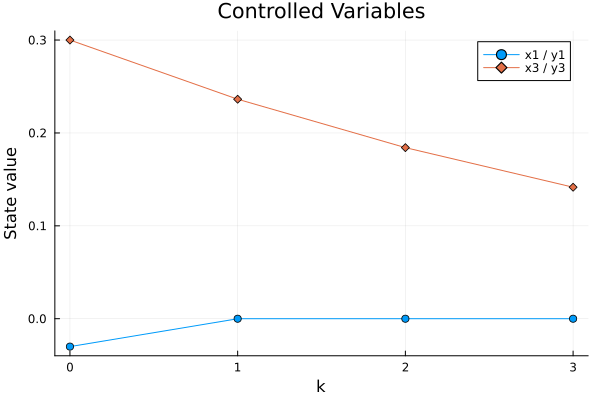

In [56]:
using Plots

# Solve
optimize!(model)

println("Status: ", termination_status(model))
println("Objective value: ", round(objective_value(model), digits=6))

# Extract results
X = [[value(x[i,k]) for i in 1:nx] for k in 0:N]
U = [[value(u[i,k]) for i in 1:nu] for k in 0:N-1]

time_x = 0:N
time_u = 0:N-1

x1_vals = [X[k+1][1] for k in 0:N]
x2_vals = [X[k+1][2] for k in 0:N]
x3_vals = [X[k+1][3] for k in 0:N]

u1_vals = [U[k+1][1] for k in 0:N-1]
u2_vals = [U[k+1][2] for k in 0:N-1]

# Print states
println("\nStates:")
for k in 0:N
    println("k = ", k, " | x = ", round.(X[k+1], digits=6))
end

# Print inputs
println("\nInputs:")
for k in 0:N-1
    println("k = ", k, " | u = ", round.(U[k+1], digits=6))
end

# Plot controlled variables
plot(
    time_x,
    x1_vals,
    marker = :circle,
    label = "x1 / y1",
    xlabel = "k",
    ylabel = "State value",
    title = "Controlled Variables"
)

plot!(
    time_x,
    x3_vals,
    marker = :diamond,
    label = "x3 / y3"
)